In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#Install & Import Dependencies

In [2]:
!pip install -q pandas numpy matplotlib seaborn scikit-learn datasets

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [4]:
# Set plot style for clean visualizations
sns.set_theme(style="whitegrid")
%matplotlib inline

# Define your source dataset path
DATASET_PATH = "/content/drive/MyDrive/AIE_Project/intent_classification_datasets/data_new_augmented_dataset.csv"

#Load Data, Remove Duplicates & Text Cleaning

In [5]:
# 1. Load the raw dataset
df_raw = pd.read_csv(DATASET_PATH)
print(f"📊 Initial Dataset Shape: {df_raw.shape[0]} rows, {df_raw.shape[1]} columns\n")

# 2. Text Cleaning Function
def clean_utterance(text):
    if not isinstance(text, str):
        return ""
    text = text.strip()                     # Remove leading/trailing whitespaces
    text = re.sub(r'\s+', ' ', text)        # Normalize multi-space gaps to single spaces
    text = text.lower()                     # Convert to lower-case for uniformity
    return text

df_raw['cleaned_text'] = df_raw['text'].apply(clean_utterance)

# 3. Duplicate Identification and Removal
duplicate_mask = df_raw.duplicated(subset=['cleaned_text'], keep=False)
total_duplicates = duplicate_mask.sum()

print(f"🔍 Duplicate Analysis:")
print(f" -> Found {total_duplicates} rows with matching text content.")

if total_duplicates > 0:
    # Retain the first occurrence, drop remaining duplicates
    df_clean = df_raw.drop_duplicates(subset=['cleaned_text'], keep='first').copy()
    print(f" -> ✅ Dropped duplicate records. Clean dataset row count: {len(df_clean)}")
else:
    df_clean = df_raw.copy()
    print(" -> ✅ No strict duplicates detected.")


📊 Initial Dataset Shape: 7936 rows, 2 columns

🔍 Duplicate Analysis:
 -> Found 0 rows with matching text content.
 -> ✅ No strict duplicates detected.


#Label Consistency & Ambiguity Discovery (Cross-Label Detection)

In [7]:
print("⚙️ Scanning for semantic conflicts and ambiguities...")

# 1. Check for hard conflicts: Identical text mapped to entirely different labels
hard_conflicts = df_clean.groupby('cleaned_text').filter(lambda x: x['label'].nunique() > 1)
if not hard_conflicts.empty:
    print(r"⚠️ CRITICAL HARD CONFLICTS FOUND! Identical strings mapped to different labels:")
    display(hard_conflicts[['text', 'label']].sort_values(by='text'))
else:
    print(" ->  No identical strings mapped to conflicting labels.")

# 2. Soft Conflicts: Find sentences with >85% textual similarity but different labels
vectorizer = TfidfVectorizer(ngram_range=(1, 2))
tfidf_matrix = vectorizer.fit_transform(df_clean['cleaned_text'])
similarity_matrix = cosine_similarity(tfidf_matrix)

ambiguous_pairs = []
# Loop through the upper triangle of the matrix to identify overlapping pairs
for i in range(len(df_clean)):
    for j in range(i + 1, len(df_clean)):
        if similarity_matrix[i, j] > 0.85: # Threshold setting for text similarity
            label_i = df_clean.iloc[i]['label']
            label_j = df_clean.iloc[j]['label']
            if label_i != label_j:
                ambiguous_pairs.append({
                    "Text A": df_clean.iloc[i]['text'],
                    "Label A": label_i,
                    "Text B": df_clean.iloc[j]['text'],
                    "Label B": label_j,
                    "Similarity": round(similarity_matrix[i, j], 2)
                })

df_ambiguous = pd.DataFrame(ambiguous_pairs)
if not df_ambiguous.empty:
    print(f"\n⚠️ AMBIGUOUS EXAMPLES DETECTED ({len(df_ambiguous)} pairs):")
    print("These text samples have high lexical overlap but are assigned different labels (e.g., refund vs payment issues):")
    display(df_ambiguous.sort_values(by='Similarity', ascending=False))
else:
    print(" ->  No borderline ambiguous sentence pairs found above the 85% threshold.")


⚙️ Scanning for semantic conflicts and ambiguities...
 ->  No identical strings mapped to conflicting labels.
 ->  No borderline ambiguous sentence pairs found above the 85% threshold.


#Class Distribution Analysis & Balance Visualization

=== CURRENT INTENT CLASS DISTRIBUTION ===


,Total Samples,Dataset Percentage (%)
label,,
complaint,1000,12.60
technical_support,1000,12.60
self_harm_or_suicide_risk,1000,12.60
general_question,980,12.35
refund,918,11.57
product_inquiry,886,11.16
payment,763,9.61
unknown,704,8.87
logistics,685,8.63


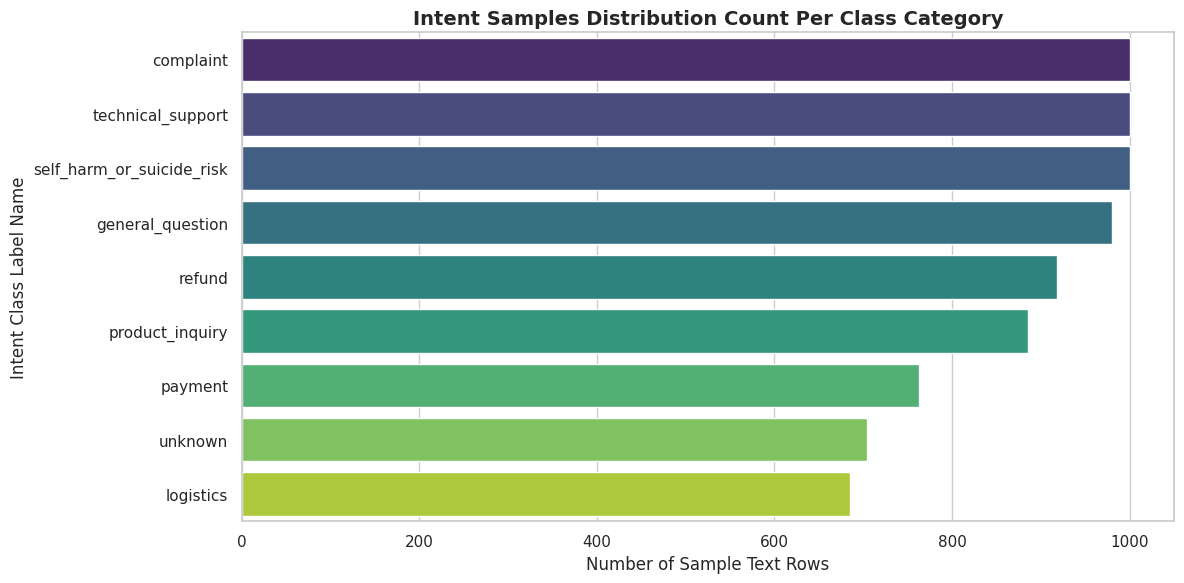

In [8]:
# 1. Calculate class statistics
class_counts = df_clean['label'].value_counts()
class_percentages = df_clean['label'].value_counts(normalize=True) * 100

df_dist = pd.DataFrame({
    'Total Samples': class_counts,
    'Dataset Percentage (%)': class_percentages.round(2)
})

print("=== CURRENT INTENT CLASS DISTRIBUTION ===")
display(df_dist)

# 2. Render distribution bar chart
plt.figure(figsize=(12, 6))
sns.barplot(x=class_counts.values, y=class_counts.index, hue=class_counts.index, palette="viridis", legend=False)
plt.title('Intent Samples Distribution Count Per Class Category', fontsize=14, weight='bold')
plt.xlabel('Number of Sample Text Rows', fontsize=12)
plt.ylabel('Intent Class Label Name', fontsize=12)
plt.tight_layout()
plt.show()


#Stratified Train, Validation, and Test Split

In [9]:
target_column = "label"

# 1. First split: Isolate the Training partition (70% of total data)
train_df, temp_df = train_test_split(
    df_clean,
    test_size=0.30,
    random_state=42,
    stratify=df_clean[target_column]
)

# 2. Second split: Divide the remaining 30% equally into Validation (15%) and Test (15%)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df[target_column]
)

print("=== THREE-WAY STRATIFIED DATASPLIT METRICS ===")
print(f" -> 🟢 Train Set Size      : {len(train_df)} rows ({round(len(train_df)/len(df_clean)*100)}%)")
print(f" -> 🟡 Validation Set Size: {len(val_df)} rows ({round(len(val_df)/len(df_clean)*100)}%)")
print(f" -> 🔴 Test Set Size        : {len(test_df)} rows ({round(len(test_df)/len(df_clean)*100)}%)")

# Verify distribution matching
train_dist = train_df[target_column].value_counts(normalize=True).round(3)
val_dist = val_df[target_column].value_counts(normalize=True).round(3)
print("\nTrain class distribution check:\n", train_dist)


=== THREE-WAY STRATIFIED DATASPLIT METRICS ===
 -> 🟢 Train Set Size      : 5555 rows (70%)
 -> 🟡 Validation Set Size: 1190 rows (15%)
 -> 🔴 Test Set Size        : 1191 rows (15%)

Train class distribution check:
 label
complaint                    0.126
self_harm_or_suicide_risk    0.126
technical_support            0.126
general_question             0.123
refund                       0.116
product_inquiry              0.112
payment                      0.096
unknown                      0.089
logistics                    0.086
Name: proportion, dtype: float64


#Balancing Data Imbalance (Oversampling Rare Classes)
Deep learning models perform best with uniform training distributions, this cell targets only  train_df set, automatically duplicating rows in rare intent categories until all classes match the size of the largest class.

In [10]:
print("⚖️ Applying Random Oversampling optimization to the Training Set...")

# 1. Determine the maximum target row count within any category
target_sample_size = train_df['label'].value_counts().max()
print(f" -> Upsampling all training classes to match the largest class size: {target_sample_size} rows.\n")

balanced_train_records = []

# 2. Perform resampling per individual group
for label_name, group in train_df.groupby('label'):
    if len(group) < target_sample_size:
        # Sample with replacement to inflate underrepresented classes
        resampled_group = group.sample(n=target_sample_size, replace=True, random_state=42)
        balanced_train_records.append(resampled_group)
    else:
        balanced_train_records.append(group)

# 3. Re-merge records back into a balanced training dataframe
train_df_balanced = pd.concat(balanced_train_records, ignore_index=True)

# Shuffle the final training dataframe to mix up the duplicated examples
train_df_balanced = train_df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print("=== POST-BALANCING RESAMPLING METRICS ===")
print(f" -> Original Training Rows Count: {len(train_df)}")
print(f" -> Balanced Training Rows Count: {len(train_df_balanced)}")
print("\nNew balanced row counts per class:")
print(train_df_balanced['label'].value_counts())

⚖️ Applying Random Oversampling optimization to the Training Set...
 -> Upsampling all training classes to match the largest class size: 700 rows.

=== POST-BALANCING RESAMPLING METRICS ===
 -> Original Training Rows Count: 5555
 -> Balanced Training Rows Count: 6300

New balanced row counts per class:
label
logistics                    700
complaint                    700
self_harm_or_suicide_risk    700
refund                       700
general_question             700
payment                      700
technical_support            700
product_inquiry              700
unknown                      700
Name: count, dtype: int64


#Save Cleaned, Segmented Partition Artifacts

In [11]:
# Define your export folder location path layout
EXPORT_DIR = "/content/drive/MyDrive/AIE_Project/intent_classification_datasets/"

train_df_balanced[['text', 'label']].to_csv(f"{EXPORT_DIR}train_cleaned_balanced.csv", index=False)
val_df[['text', 'label']].to_csv(f"{EXPORT_DIR}val_cleaned.csv", index=False)
test_df[['text', 'label']].to_csv(f"{EXPORT_DIR}test_cleaned.csv", index=False)

print("🎉 Data processing complete!")
print(f"Saved optimized splits to storage directory: {EXPORT_DIR}")
print("   - train_cleaned_balanced.csv (training dataset)")
print("   - val_cleaned.csv            (Unaltered validation reference data)")
print("   - test_cleaned.csv           (Final holdout tracking validation metrics)")

🎉 Data processing complete!
Saved optimized splits to storage directory: /content/drive/MyDrive/AIE_Project/intent_classification_datasets/
   - train_cleaned_balanced.csv (training dataset)
   - val_cleaned.csv            (Unaltered validation reference data)
   - test_cleaned.csv           (Final holdout tracking validation metrics)
